Exploratory Data Analysis


In [5]:

# Import required libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Save model
import pickle

In [6]:
# Load dataset

# Read CSV file
df = pd.read_csv("insurance_claims.csv")

# Display first 5 rows
print(df.head())

# Dataset shape
print("Dataset Shape:", df.shape)

   months_as_customer  age  policy_number policy_bind_date policy_state  \
0                 328   48         521585       2014-10-17           OH   
1                 228   42         342868       2006-06-27           IN   
2                 134   29         687698       2000-09-06           OH   
3                 256   41         227811       1990-05-25           IL   
4                 228   44         367455       2014-06-06           IL   

  policy_csl  policy_deductable  policy_annual_premium  umbrella_limit  \
0    250/500               1000                1406.91               0   
1    250/500               2000                1197.22         5000000   
2    100/300               2000                1413.14         5000000   
3    250/500               2000                1415.74         6000000   
4   500/1000               1000                1583.91         6000000   

   insured_zip  ... police_report_available total_claim_amount injury_claim  \
0       466132  ...      

In [7]:
# Basic data exploration

# Check data types
print(df.info())

# Summary statistics
print(df.describe())

# Check missing values
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [8]:
# Data Cleaning


# Drop unnecessary column
df.drop(columns=['_c39'], inplace=True)

# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Fill missing values
df.fillna(method='ffill', inplace=True)

# Convert date columns into datetime
df['policy_bind_date'] = pd.to_datetime(df['policy_bind_date'])
df['incident_date'] = pd.to_datetime(df['incident_date'])

/tmp/ipykernel_1404/2024601696.py:11: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


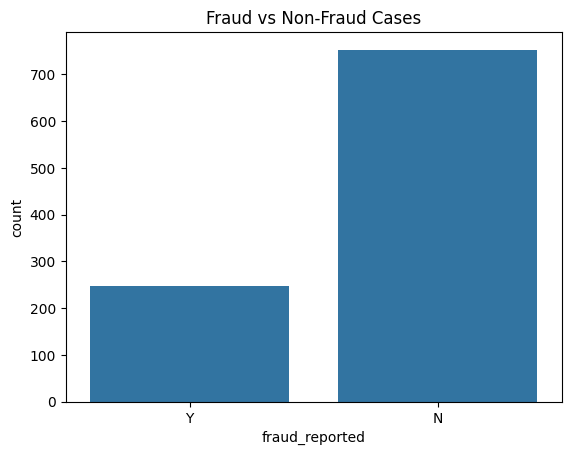

In [9]:
# Distribution of fraud cases

sns.countplot(x='fraud_reported', data=df)
plt.title("Fraud vs Non-Fraud Cases")
plt.show()

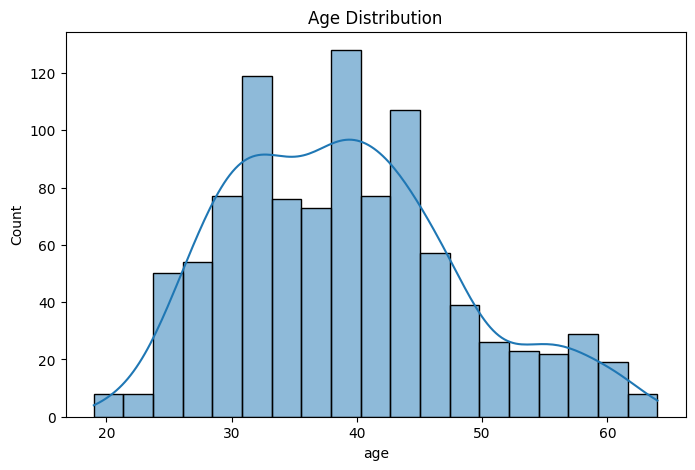

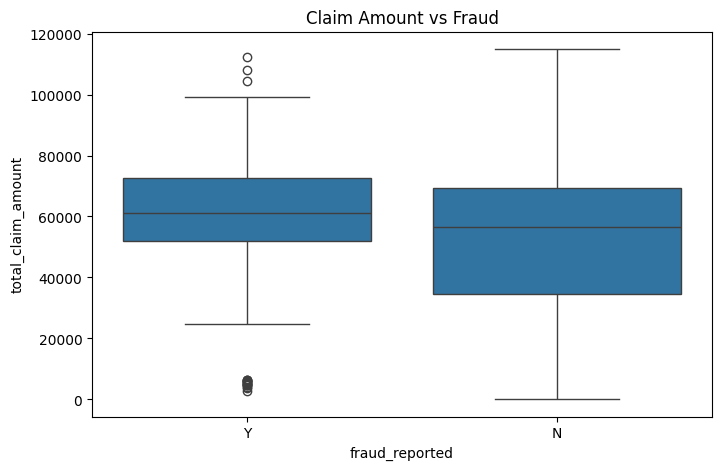

In [10]:
# Visual analysis


# Age distribution
plt.figure(figsize=(8,5))
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()


# Total claim amount vs fraud
plt.figure(figsize=(8,5))
sns.boxplot(x='fraud_reported', y='total_claim_amount', data=df)
plt.title("Claim Amount vs Fraud")
plt.show()

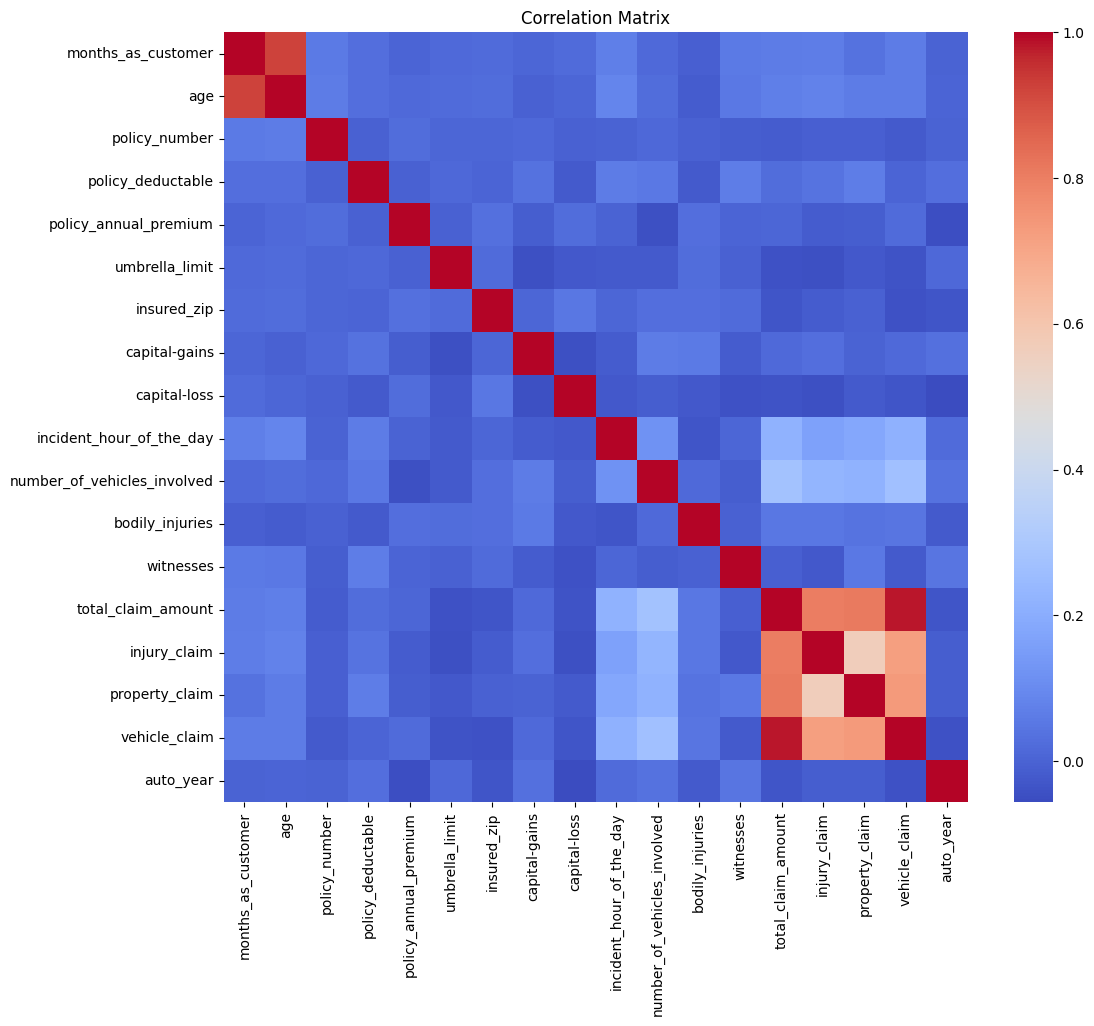

In [12]:
# Correlation heatmap

# Select numeric columns
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,10))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [13]:
# Encoding categorical variables


# Initialize Label Encoder
le = LabelEncoder()

# Convert all object columns
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column].astype(str))

print(df.head())

   months_as_customer  age  policy_number policy_bind_date  policy_state  \
0                 328   48         521585       2014-10-17             2   
1                 228   42         342868       2006-06-27             1   
2                 134   29         687698       2000-09-06             2   
3                 256   41         227811       1990-05-25             0   
4                 228   44         367455       2014-06-06             0   

   policy_csl  policy_deductable  policy_annual_premium  umbrella_limit  \
0           1               1000                1406.91               0   
1           1               2000                1197.22         5000000   
2           0               2000                1413.14         5000000   
3           1               2000                1415.74         6000000   
4           2               1000                1583.91         6000000   

   insured_zip  ...  witnesses  police_report_available  total_claim_amount  \
0       46613

In [14]:
# Convert date columns to datetime
df['policy_bind_date'] = pd.to_datetime(df['policy_bind_date'])
df['incident_date'] = pd.to_datetime(df['incident_date'])

# Convert to number of days
df['policy_bind_date'] = df['policy_bind_date'].map(pd.Timestamp.toordinal)
df['incident_date'] = df['incident_date'].map(pd.Timestamp.toordinal)

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column].astype(str))

In [16]:
print(df.dtypes)

months_as_customer               int64
age                              int64
policy_number                    int64
policy_bind_date                 int64
policy_state                     int64
policy_csl                       int64
policy_deductable                int64
policy_annual_premium          float64
umbrella_limit                   int64
insured_zip                      int64
insured_sex                      int64
insured_education_level          int64
insured_occupation               int64
insured_hobbies                  int64
insured_relationship             int64
capital-gains                    int64
capital-loss                     int64
incident_date                    int64
incident_type                    int64
collision_type                   int64
incident_severity                int64
authorities_contacted            int64
incident_state                   int64
incident_city                    int64
incident_location                int64
incident_hour_of_the_day 

In [17]:
# Feature Scaling

# Separate features and target
X = df.drop("fraud_reported", axis=1)
y = df["fraud_reported"]

# Initialize scaler
scaler = StandardScaler()

# Scale features
X_scaled = scaler.fit_transform(X)

In [18]:
# Split dataset into train and test

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

MODEL BUILDING


In [19]:
# Decision Tree Model


dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.775


In [21]:
# Random Forest Model


rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.745


In [22]:
# KNN Model


knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.69


In [23]:
# Logistic Regression

lr_model = LogisticRegression(max_iter=500)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.71


In [24]:
# Naive Bayes Model

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.71


In [25]:
# SVM Model

svm_model = SVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.715


TESTING THE MODEL

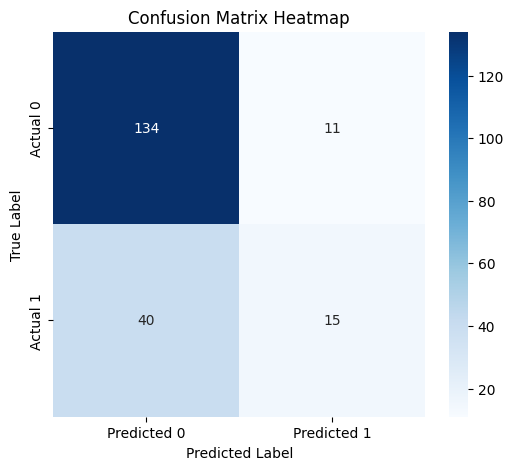

In [26]:
# Confusion matrix

cm = confusion_matrix(y_test, rf_pred)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Predicted 0','Predicted 1'],
            yticklabels=['Actual 0','Actual 1'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

models = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "KNN",
        "Logistic Regression",
        "Naive Bayes",
        "SVM"
    ],

    "Accuracy": [
        dt_accuracy,
        rf_accuracy,
        knn_accuracy,
        lr_accuracy,
        nb_accuracy,
        svm_accuracy
    ]
})

MODEL COMPARISION

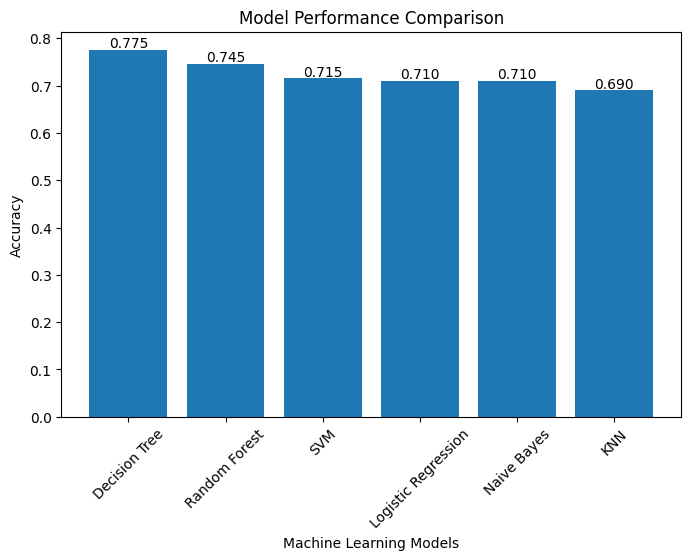

In [28]:
models_sorted = models.sort_values(by="Accuracy", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(models_sorted["Model"], models_sorted["Accuracy"])

plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")
plt.title("Model Performance Comparison")
plt.xticks(rotation=45)

# show accuracy values on bars
for i, v in enumerate(models_sorted["Accuracy"]):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')

plt.show()

HYPERPARAMETER TUNING

In [29]:
# ===============================
# Hyperparameter tuning
# ===============================

param_grid = {
    'n_estimators': [100,200],
    'max_depth': [10,20,None],
    'min_samples_split': [2,5]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

best_model = grid.best_estimator_

pred = best_model.predict(X_test)

print("Accuracy after tuning:", accuracy_score(y_test, pred))

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Accuracy after tuning: 0.76


In [30]:
# Save trained model

pickle.dump(best_model, open("fraud_model.pkl", "wb"))

In [33]:
pip install flask

In [36]:
!pip install flask-ngrok

In [40]:
!pip install pyngrok flask

In [42]:
from pyngrok import ngrok

ngrok.set_auth_token("3AeOYdsC26O2VIffu2PY26bGMKw_U4mcqSmt6X9PKgARseCb")

In [44]:
from flask import Flask, request, jsonify
from pyngrok import ngrok
import pickle
import numpy as np

app = Flask(__name__)

model = pickle.load(open("fraud_model.pkl","rb"))

@app.route("/")
def home():
    return "Insurance Fraud Detection API Running"

@app.route("/predict", methods=["POST"])
def predict():

    data = request.json
    features = np.array(data["features"]).reshape(1,-1)

    prediction = model.predict(features)

    result = "Fraud" if prediction[0]==1 else "Not Fraud"

    return jsonify({"Prediction": result})

public_url = ngrok.connect(5000)
print("Public URL:", public_url)

app.run()

Public URL: NgrokTunnel: "https://lampless-rosanne-relatedly.ngrok-free.dev" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [08/Mar/2026 06:32:21] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [08/Mar/2026 06:32:21] "GET /favicon.ico HTTP/1.1" 404 -


In [46]:
app.run(use_reloader=False)

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit


In [ ]:
import requests

url = "https://1ampless-rosanne-relatedly.ngrok-free.dev/predict"

data = {
    "features":[30,1,50000,1,3,10000,5,1,2,4]
}

response = requests.post(url, json=data)

print(response.json())

In [49]:
import pickle
import numpy as np
import pandas as pd

# load model
model = pickle.load(open("fraud_model.pkl","rb"))

# load dataset
df = pd.read_csv("insurance_claims.csv")

# same preprocessing steps you used earlier
df.drop(columns=['_c39'], inplace=True)
df.replace('?', np.nan, inplace=True)
df.fillna(method='ffill', inplace=True)

df['policy_bind_date'] = pd.to_datetime(df['policy_bind_date'])
df['incident_date'] = pd.to_datetime(df['incident_date'])

df['policy_bind_date'] = df['policy_bind_date'].map(pd.Timestamp.toordinal)
df['incident_date'] = df['incident_date'].map(pd.Timestamp.toordinal)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column].astype(str))

# take one sample row
X = df.drop("fraud_reported", axis=1)

sample = X.iloc[0].values.reshape(1,-1)

prediction = model.predict(sample)

if prediction[0] == 1:
    print("Prediction: Fraud")
else:
    print("Prediction: Not Fraud")

Prediction: Fraud


/tmp/ipykernel_1404/100077779.py:14: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
